In [ ]:
import pandas as pd
import zipfile, os, pickle
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch import nn
from transformers import BertModel, logging
from torch.optim import AdamW
from torch.nn import CrossEntropyLoss
from tqdm import tqdm
import matplotlib.pyplot as plt
import copy
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW

In [ ]:
CSV_NAME_IN_ZIP = "blogtext.csv"
NROWS = 20000    # chatGPT suggests to use 20000 for T100 GPU
MAX_LEN = 128
BATCH_SIZE = 4
EPOCHS = 30
LR = 1e-6
CHECKPOINT_PATH = "checkpoint.pkl"
MODEL_DIR = "multitask_model"
USE_CHECKPOINT = False

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/My Drive/blogtext.csv")
df.shape

(681284, 7)

In [ ]:
df = df[['gender', 'age', 'topic', 'text']]
df = df.dropna().reset_index(drop=True)
df.shape

(681284, 4)

In [ ]:
df = df.sample(n=NROWS, random_state=42).reset_index(drop=True)
df.shape

(20000, 4)

In [ ]:
gender_enc = LabelEncoder()
age_enc = LabelEncoder()
ind_enc = LabelEncoder()

df['gender_label'] = gender_enc.fit_transform(df['gender'])
df['age_label'] = age_enc.fit_transform(df['age'])
df['ind_label'] = ind_enc.fit_transform(df['topic'])

train_texts, val_texts, y_gender_train, y_gender_val, y_age_train, y_age_val, y_ind_train, y_ind_val = train_test_split(
    df['text'], df['gender_label'], df['age_label'], df['ind_label'],
    test_size=0.2,
    random_state=42,
    stratify=df['gender_label']  # ensures class distribution is preserved
)

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

print("Starting tokenization...")
train_encodings = tokenizer(
    list(train_texts),
    truncation=True,
    padding='max_length',
    max_length=MAX_LEN,
    return_tensors='pt'    # directly return PyTorch tensors
)
print("Train tokenized")

val_encodings = tokenizer(
    list(val_texts),
    truncation=True,
    padding='max_length',
    max_length=MAX_LEN,
    return_tensors='pt'
)
print("Validation tokenized")

train_labels = {
    "gender": torch.tensor(y_gender_train.values),
    "age": torch.tensor(y_age_train.values),
    "ind": torch.tensor(y_ind_train.values)
}

val_labels = {
    "gender": torch.tensor(y_gender_val.values),
    "age": torch.tensor(y_age_val.values),
    "ind": torch.tensor(y_ind_val.values)
}

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Starting tokenization...
Train tokenized
Validation tokenized


In [ ]:
train_gender_labels = torch.tensor(y_gender_train.values)
train_age_labels    = torch.tensor(y_age_train.values)
train_ind_labels    = torch.tensor(y_ind_train.values)

val_gender_labels = torch.tensor(y_gender_val.values)
val_age_labels    = torch.tensor(y_age_val.values)
val_ind_labels    = torch.tensor(y_ind_val.values)

class BlogDataset(Dataset):
    def __init__(self, encodings, gender_labels, age_labels, ind_labels):
        self.encodings = encodings
        self.gender_labels = gender_labels
        self.age_labels = age_labels
        self.ind_labels = ind_labels

    def __len__(self):
        return len(self.gender_labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels_gender': self.gender_labels[idx],
            'labels_age': self.age_labels[idx],
            'labels_ind': self.ind_labels[idx]
        }

train_dataset = BlogDataset(train_encodings, train_gender_labels, train_age_labels, train_ind_labels)
val_dataset   = BlogDataset(val_encodings, val_gender_labels, val_age_labels, val_ind_labels)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE)

n_gender = len(gender_enc.classes_)
n_age    = len(age_enc.classes_)
n_ind    = len(ind_enc.classes_)

In [ ]:
class MultiTaskBERT(nn.Module):
    def __init__(self, n_gender, n_age, n_ind, freeze_layers = True, dropout_prob=0.5):
        super(MultiTaskBERT, self).__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        hidden_size = self.bert.config.hidden_size
        self.dropout = nn.Dropout(dropout_prob)

        if freeze_layers:
            for param in self.bert.embeddings.parameters():
                param.requires_grad = False
            for layer in self.bert.encoder.layer[:10]:   # freeze first 8 out of 12
                for param in layer.parameters():
                    param.requires_grad = False

        self.gender_classifier = nn.Linear(hidden_size, n_gender)
        self.age_classifier    = nn.Linear(hidden_size, n_age)
        self.ind_classifier    = nn.Linear(hidden_size, n_ind)

        # Add this for dynamic loss weighting
        self.log_var_gender = nn.Parameter(torch.zeros(1))
        self.log_var_age    = nn.Parameter(torch.zeros(1))
        self.log_var_ind    = nn.Parameter(torch.zeros(1))

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output
        pooled_output = self.dropout(pooled_output)

        gender_logits = self.gender_classifier(pooled_output)
        age_logits    = self.age_classifier(pooled_output)
        ind_logits    = self.ind_classifier(pooled_output)

        return gender_logits, age_logits, ind_logits

In [ ]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model = MultiTaskBERT(n_gender, n_age, n_ind).to(device)

loss_fn_gender = CrossEntropyLoss()
loss_fn_age = CrossEntropyLoss()
loss_fn_ind = CrossEntropyLoss()

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
num_training_steps = len(train_loader) * EPOCHS
num_warmup_steps = int(0.1 * num_training_steps)  # 10% warmup

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

model.train()

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

MultiTaskBERT(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise

train function
validation function
epochs starting...
Epoch 1/30
  Train Loss: 3.7593 | Val Loss: 3.4942
  Train Acc -> Gender: 0.5124, Age: 0.0624, Ind: 0.0644
  Val   Acc -> Gender: 0.5463, Age: 0.0983, Ind: 0.3165


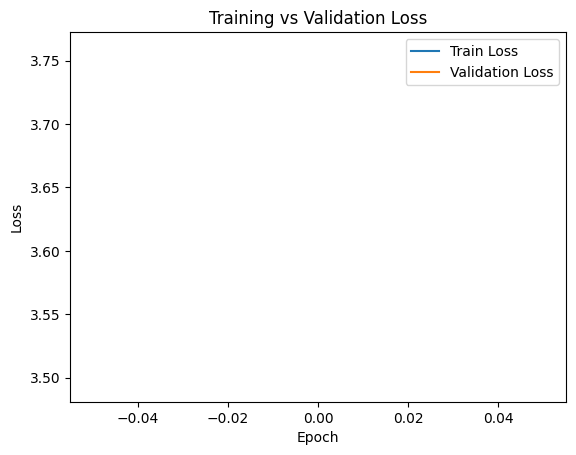

Epoch 2/30
  Train Loss: 3.3204 | Val Loss: 3.0021
  Train Acc -> Gender: 0.5250, Age: 0.0924, Ind: 0.3219
  Val   Acc -> Gender: 0.5773, Age: 0.1177, Ind: 0.3740


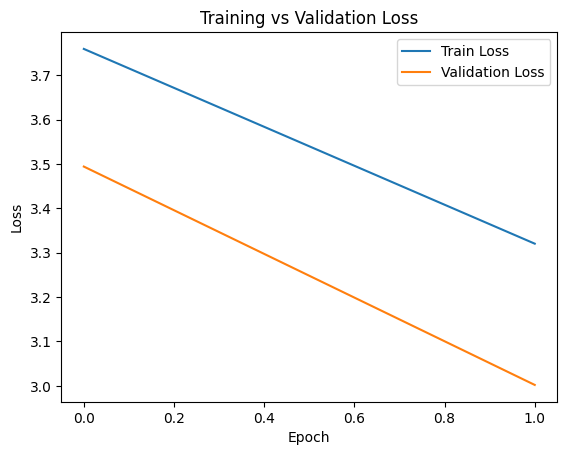

Epoch 3/30
  Train Loss: 3.0091 | Val Loss: 2.8615
  Train Acc -> Gender: 0.5436, Age: 0.1171, Ind: 0.3606
  Val   Acc -> Gender: 0.5917, Age: 0.1430, Ind: 0.3743


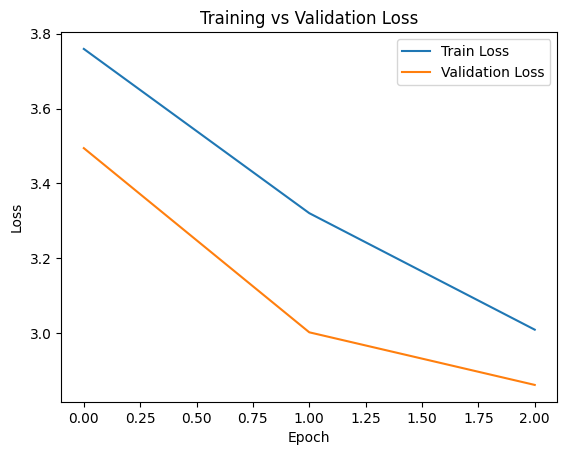

Epoch 4/30
  Train Loss: 2.9099 | Val Loss: 2.8126
  Train Acc -> Gender: 0.5727, Age: 0.1212, Ind: 0.3616
  Val   Acc -> Gender: 0.6000, Age: 0.1520, Ind: 0.3785


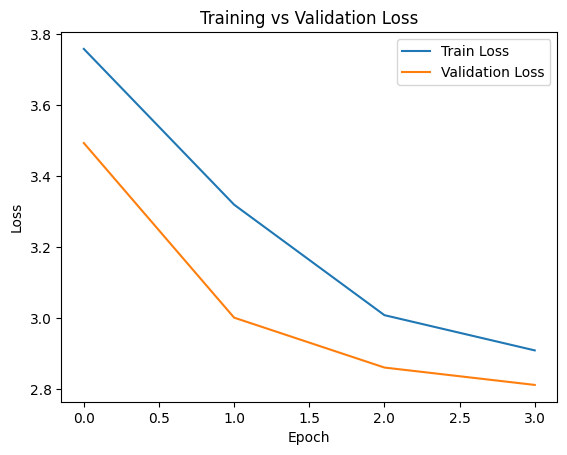

Epoch 5/30
  Train Loss: 2.8656 | Val Loss: 2.7863
  Train Acc -> Gender: 0.5976, Age: 0.1266, Ind: 0.3672
  Val   Acc -> Gender: 0.6042, Age: 0.1565, Ind: 0.3842


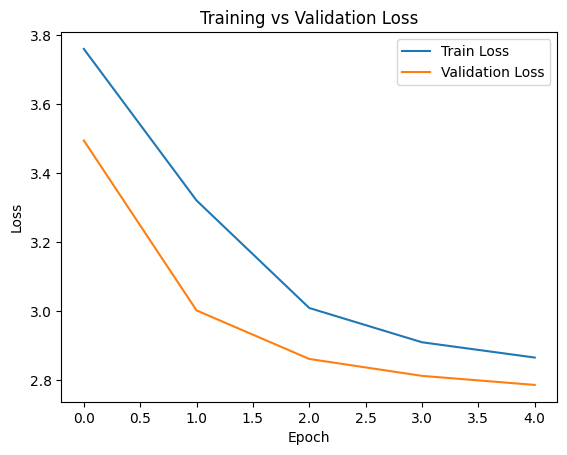

Epoch 6/30
  Train Loss: 2.8369 | Val Loss: 2.7647
  Train Acc -> Gender: 0.6092, Age: 0.1306, Ind: 0.3699
  Val   Acc -> Gender: 0.6098, Age: 0.1573, Ind: 0.3880


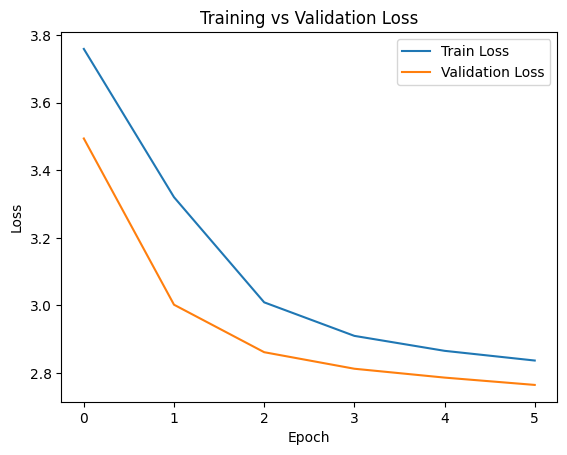

Epoch 7/30
  Train Loss: 2.8132 | Val Loss: 2.7475
  Train Acc -> Gender: 0.6188, Age: 0.1376, Ind: 0.3754
  Val   Acc -> Gender: 0.6115, Age: 0.1605, Ind: 0.3892


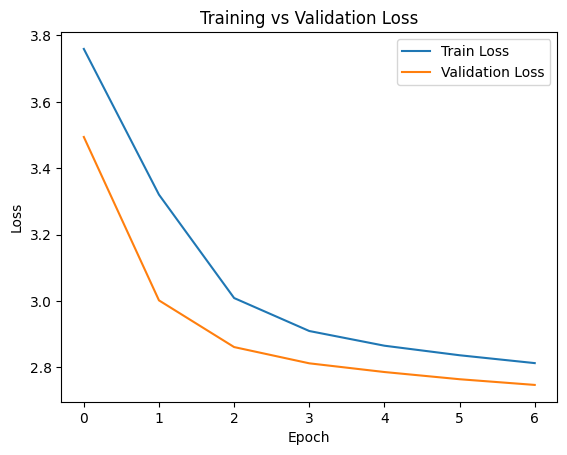

Epoch 8/30
  Train Loss: 2.7940 | Val Loss: 2.7333
  Train Acc -> Gender: 0.6228, Age: 0.1386, Ind: 0.3782
  Val   Acc -> Gender: 0.6185, Age: 0.1580, Ind: 0.3837


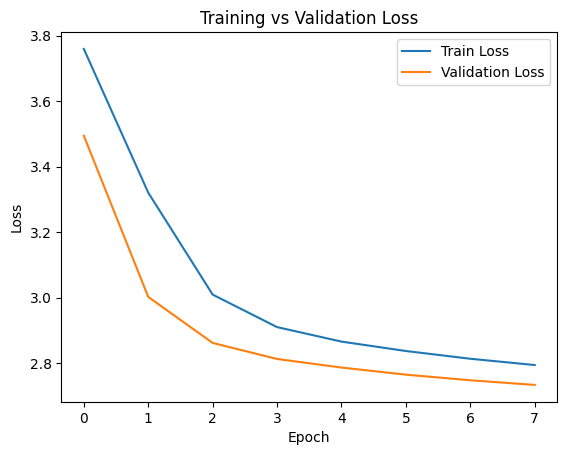

Epoch 9/30
  Train Loss: 2.7769 | Val Loss: 2.7180
  Train Acc -> Gender: 0.6282, Age: 0.1431, Ind: 0.3763
  Val   Acc -> Gender: 0.6248, Age: 0.1643, Ind: 0.3842


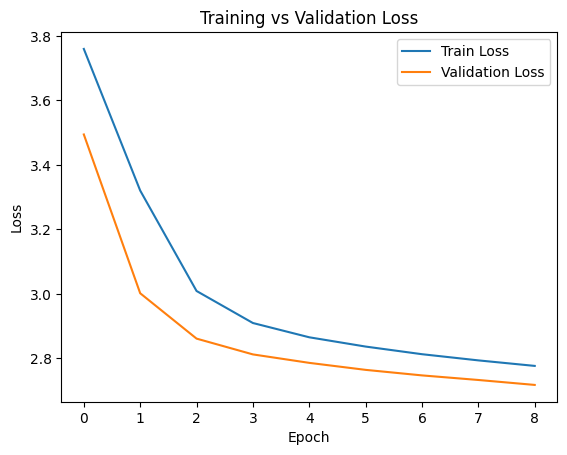

Epoch 10/30
  Train Loss: 2.7616 | Val Loss: 2.7065
  Train Acc -> Gender: 0.6326, Age: 0.1411, Ind: 0.3800
  Val   Acc -> Gender: 0.6230, Age: 0.1663, Ind: 0.3880


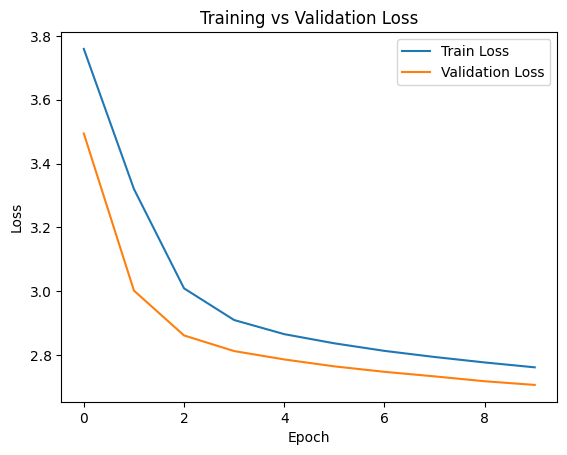

Epoch 11/30
  Train Loss: 2.7480 | Val Loss: 2.6933
  Train Acc -> Gender: 0.6315, Age: 0.1501, Ind: 0.3837
  Val   Acc -> Gender: 0.6310, Age: 0.1665, Ind: 0.3900


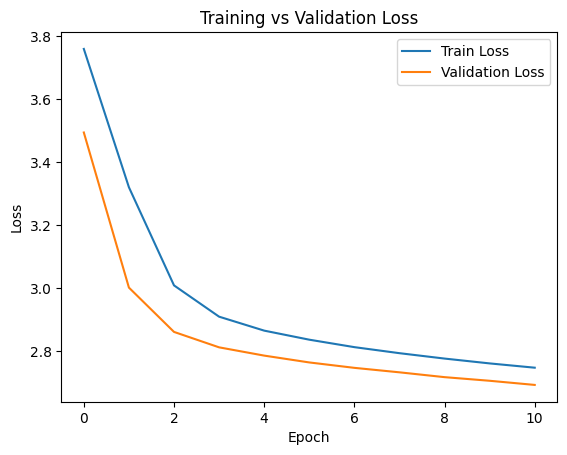

Epoch 12/30
  Train Loss: 2.7365 | Val Loss: 2.6843
  Train Acc -> Gender: 0.6354, Age: 0.1433, Ind: 0.3811
  Val   Acc -> Gender: 0.6255, Age: 0.1670, Ind: 0.3892


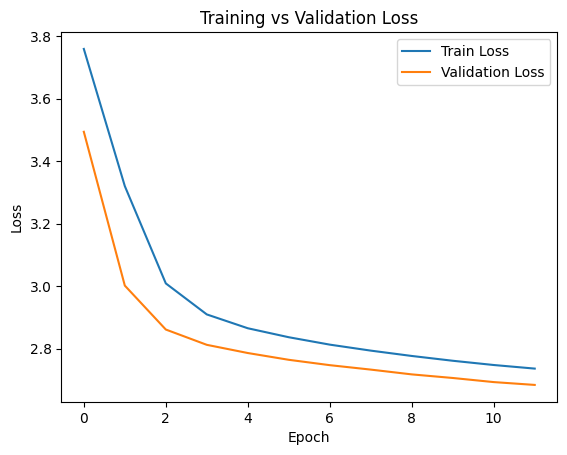

Epoch 13/30
  Train Loss: 2.7226 | Val Loss: 2.6750
  Train Acc -> Gender: 0.6381, Age: 0.1519, Ind: 0.3809
  Val   Acc -> Gender: 0.6288, Age: 0.1698, Ind: 0.3870


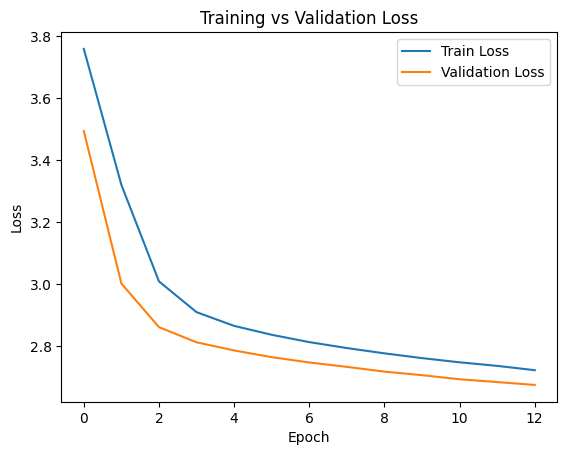

Epoch 14/30
  Train Loss: 2.7101 | Val Loss: 2.6674
  Train Acc -> Gender: 0.6389, Age: 0.1552, Ind: 0.3856
  Val   Acc -> Gender: 0.6288, Age: 0.1673, Ind: 0.3905


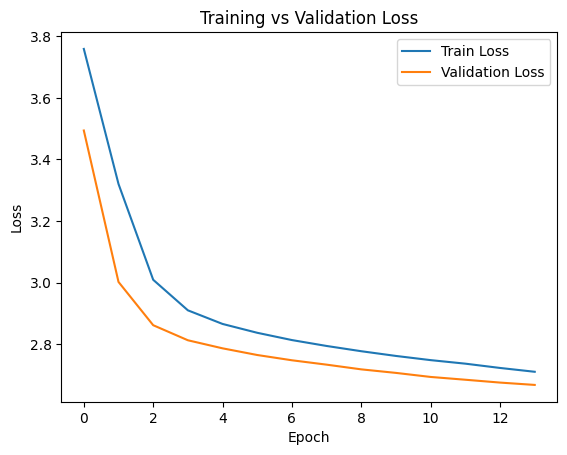

Epoch 15/30
  Train Loss: 2.7018 | Val Loss: 2.6610
  Train Acc -> Gender: 0.6435, Age: 0.1562, Ind: 0.3856
  Val   Acc -> Gender: 0.6282, Age: 0.1685, Ind: 0.3905


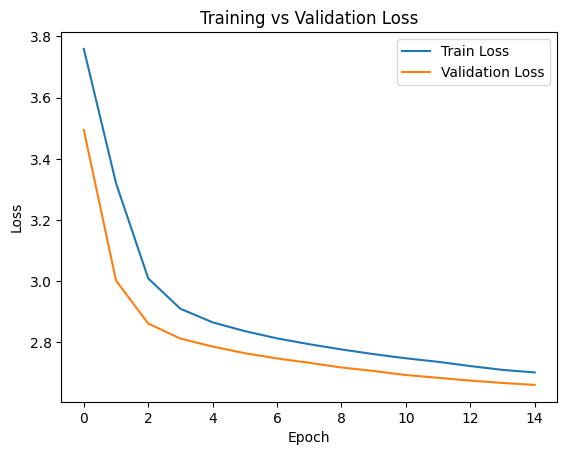

Epoch 16/30
  Train Loss: 2.6926 | Val Loss: 2.6550
  Train Acc -> Gender: 0.6463, Age: 0.1536, Ind: 0.3864
  Val   Acc -> Gender: 0.6265, Age: 0.1685, Ind: 0.3902


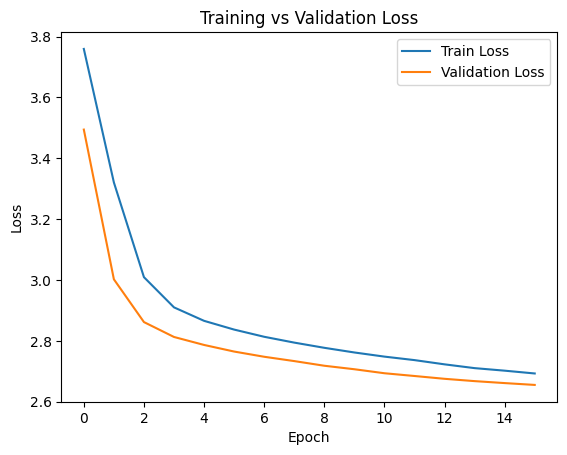

Epoch 17/30
  Train Loss: 2.6880 | Val Loss: 2.6487
  Train Acc -> Gender: 0.6493, Age: 0.1551, Ind: 0.3859
  Val   Acc -> Gender: 0.6310, Age: 0.1710, Ind: 0.3930


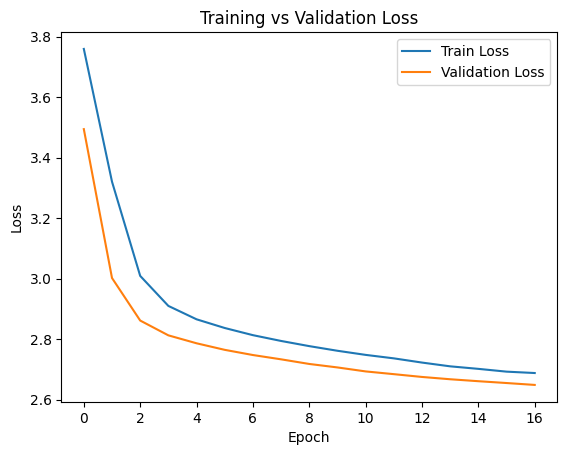

Epoch 18/30
  Train Loss: 2.6760 | Val Loss: 2.6447
  Train Acc -> Gender: 0.6540, Age: 0.1619, Ind: 0.3876
  Val   Acc -> Gender: 0.6288, Age: 0.1737, Ind: 0.3940


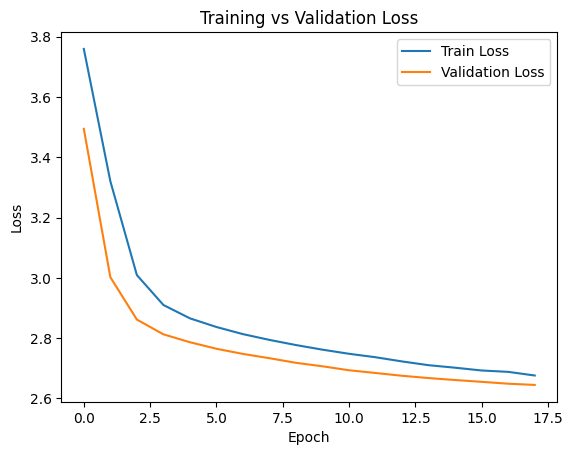

Epoch 19/30
  Train Loss: 2.6737 | Val Loss: 2.6403
  Train Acc -> Gender: 0.6479, Age: 0.1601, Ind: 0.3898
  Val   Acc -> Gender: 0.6288, Age: 0.1730, Ind: 0.3950


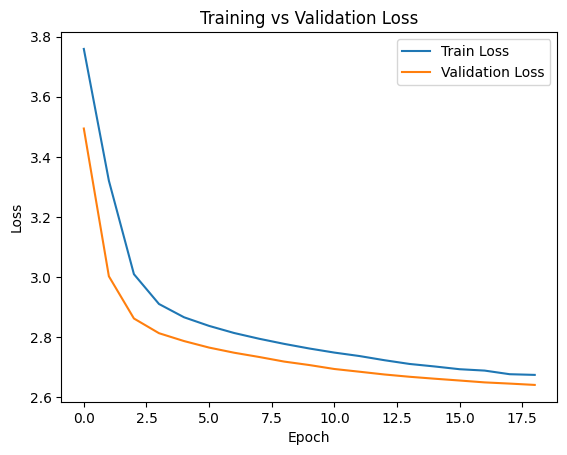

Epoch 20/30
  Train Loss: 2.6684 | Val Loss: 2.6362
  Train Acc -> Gender: 0.6513, Age: 0.1613, Ind: 0.3909
  Val   Acc -> Gender: 0.6300, Age: 0.1767, Ind: 0.3947


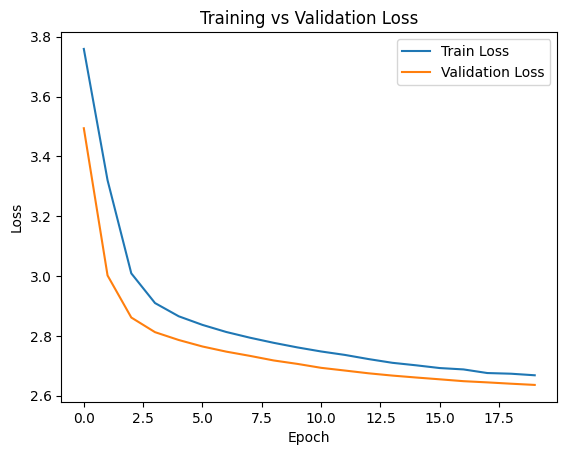

Epoch 21/30
  Train Loss: 2.6627 | Val Loss: 2.6327
  Train Acc -> Gender: 0.6482, Age: 0.1596, Ind: 0.3932
  Val   Acc -> Gender: 0.6308, Age: 0.1775, Ind: 0.3957


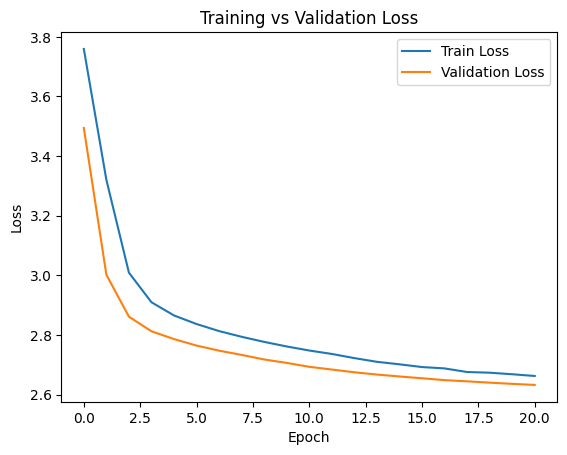

Epoch 22/30
  Train Loss: 2.6606 | Val Loss: 2.6307
  Train Acc -> Gender: 0.6551, Age: 0.1606, Ind: 0.3860
  Val   Acc -> Gender: 0.6245, Age: 0.1760, Ind: 0.3957


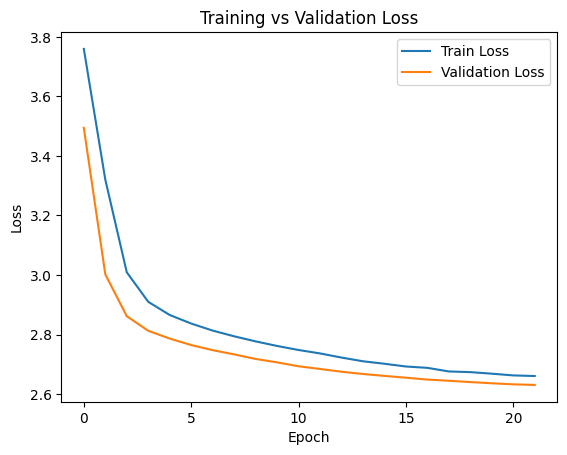

Epoch 23/30
  Train Loss: 2.6526 | Val Loss: 2.6272
  Train Acc -> Gender: 0.6523, Age: 0.1599, Ind: 0.3890
  Val   Acc -> Gender: 0.6282, Age: 0.1795, Ind: 0.3967


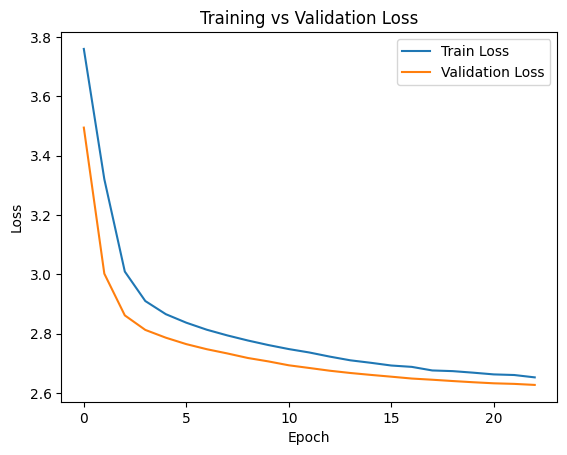

Epoch 24/30
  Train Loss: 2.6486 | Val Loss: 2.6271
  Train Acc -> Gender: 0.6578, Age: 0.1645, Ind: 0.3884
  Val   Acc -> Gender: 0.6265, Age: 0.1765, Ind: 0.3955


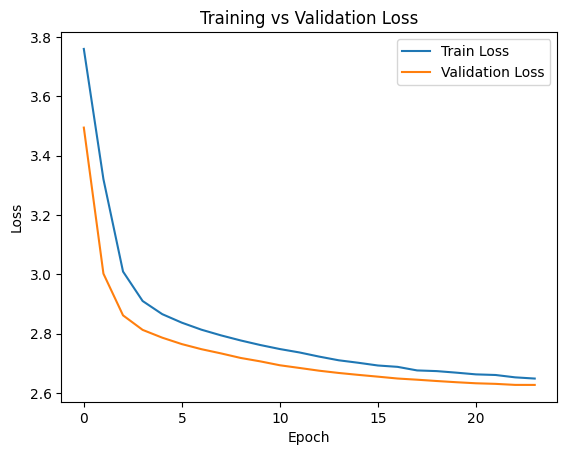

Epoch 25/30
  Train Loss: 2.6447 | Val Loss: 2.6233
  Train Acc -> Gender: 0.6561, Age: 0.1655, Ind: 0.3933
  Val   Acc -> Gender: 0.6288, Age: 0.1775, Ind: 0.3962


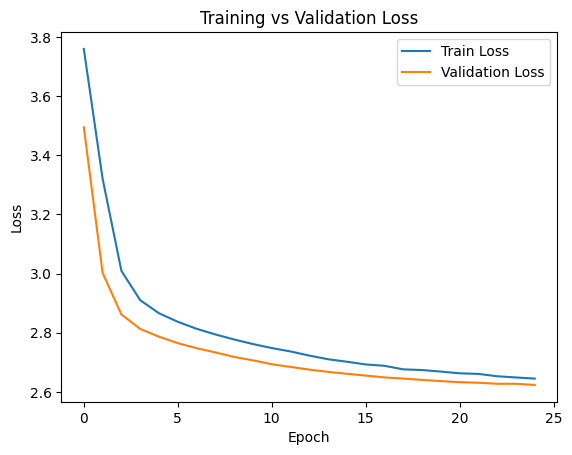

Epoch 26/30
  Train Loss: 2.6472 | Val Loss: 2.6221
  Train Acc -> Gender: 0.6559, Age: 0.1630, Ind: 0.3899
  Val   Acc -> Gender: 0.6290, Age: 0.1800, Ind: 0.3960


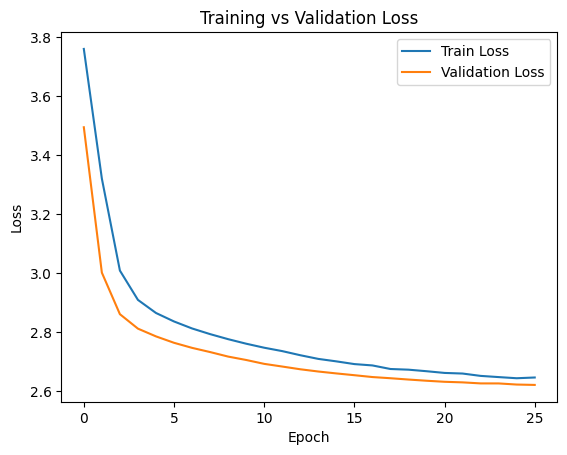

Epoch 27/30
  Train Loss: 2.6414 | Val Loss: 2.6209
  Train Acc -> Gender: 0.6521, Age: 0.1574, Ind: 0.3903
  Val   Acc -> Gender: 0.6288, Age: 0.1792, Ind: 0.3965


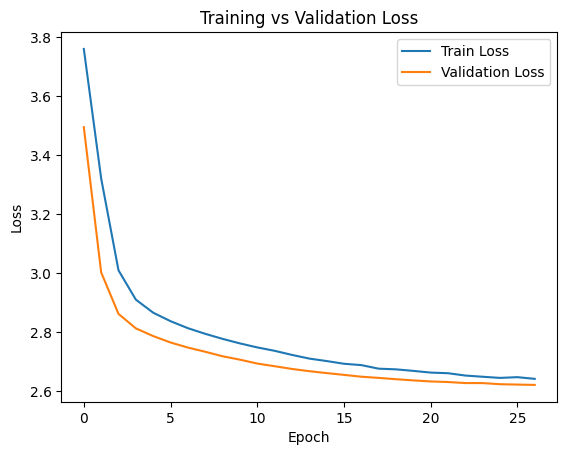

Epoch 28/30
  Train Loss: 2.6392 | Val Loss: 2.6202
  Train Acc -> Gender: 0.6568, Age: 0.1642, Ind: 0.3914
  Val   Acc -> Gender: 0.6292, Age: 0.1802, Ind: 0.3957


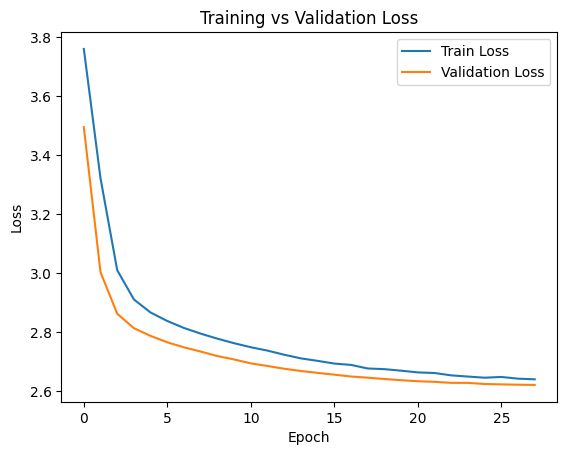

Epoch 29/30
  Train Loss: 2.6423 | Val Loss: 2.6199
  Train Acc -> Gender: 0.6577, Age: 0.1648, Ind: 0.3918
  Val   Acc -> Gender: 0.6292, Age: 0.1800, Ind: 0.3950


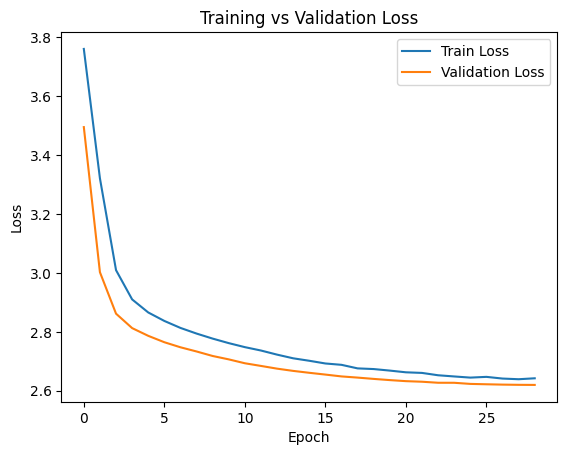

Epoch 30/30
  Train Loss: 2.6374 | Val Loss: 2.6195
  Train Acc -> Gender: 0.6547, Age: 0.1648, Ind: 0.3936
  Val   Acc -> Gender: 0.6305, Age: 0.1800, Ind: 0.3952


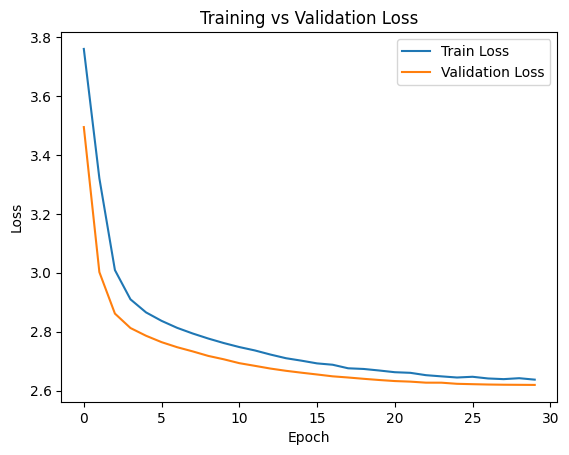

In [ ]:
from sklearn.metrics import accuracy_score
import copy
import torch
import matplotlib.pyplot as plt

# --- Training function ---
print('train function')
def train_one_epoch(model, train_loader, optimizer, device):
    model.train()
    total_loss = 0
    all_gender_preds, all_gender_labels = [], []
    all_age_preds, all_age_labels = [], []
    all_ind_preds, all_ind_labels = [], []

    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels_gender = batch['labels_gender'].to(device)
        labels_age = batch['labels_age'].to(device)
        labels_ind = batch['labels_ind'].to(device)

        # Forward pass
        gender_logits, age_logits, ind_logits = model(input_ids, attention_mask)

        # Losses
        loss_gender = loss_fn_gender(gender_logits, labels_gender)
        loss_age = loss_fn_age(age_logits, labels_age)
        loss_ind = loss_fn_ind(ind_logits, labels_ind)

       # Dynamic loss weighting
        loss = (
            0.5 * torch.exp(-model.log_var_gender) * loss_gender + 0.5 * model.log_var_gender +
            0.5 * torch.exp(-model.log_var_age) * loss_age + 0.5 * model.log_var_age +
            0.5 * torch.exp(-model.log_var_ind) * loss_ind + 0.5 * model.log_var_ind
        )

        optimizer.zero_grad()
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        # Predictions
        all_gender_preds.extend(torch.argmax(gender_logits, dim=1).cpu().numpy())
        all_age_preds.extend(torch.argmax(age_logits, dim=1).cpu().numpy())
        all_ind_preds.extend(torch.argmax(ind_logits, dim=1).cpu().numpy())

        all_gender_labels.extend(labels_gender.cpu().numpy())
        all_age_labels.extend(labels_age.cpu().numpy())
        all_ind_labels.extend(labels_ind.cpu().numpy())

    avg_loss = total_loss / len(train_loader)
    gender_acc = accuracy_score(all_gender_labels, all_gender_preds)
    age_acc = accuracy_score(all_age_labels, all_age_preds)
    ind_acc = accuracy_score(all_ind_labels, all_ind_preds)

    return avg_loss, gender_acc, age_acc, ind_acc


# --- Validation function ---
print('validation function')
def validate(model, val_loader, device):
    model.eval()
    total_loss = 0
    all_gender_preds, all_gender_labels = [], []
    all_age_preds, all_age_labels = [], []
    all_ind_preds, all_ind_labels = [], []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_gender = batch['labels_gender'].to(device)
            labels_age = batch['labels_age'].to(device)
            labels_ind = batch['labels_ind'].to(device)

            # Forward pass
            gender_logits, age_logits, ind_logits = model(input_ids, attention_mask)

            # Losses
            loss_gender = loss_fn_gender(gender_logits, labels_gender)
            loss_age = loss_fn_age(age_logits, labels_age)
            loss_ind = loss_fn_ind(ind_logits, labels_ind)

            loss = (
                0.5 * torch.exp(-model.log_var_gender) * loss_gender + 0.5 * model.log_var_gender +
                0.5 * torch.exp(-model.log_var_age) * loss_age + 0.5 * model.log_var_age +
                0.5 * torch.exp(-model.log_var_ind) * loss_ind + 0.5 * model.log_var_ind
            )

            total_loss += loss.item()

            # Predictions
            all_gender_preds.extend(torch.argmax(gender_logits, dim=1).cpu().numpy())
            all_age_preds.extend(torch.argmax(age_logits, dim=1).cpu().numpy())
            all_ind_preds.extend(torch.argmax(ind_logits, dim=1).cpu().numpy())

            all_gender_labels.extend(labels_gender.cpu().numpy())
            all_age_labels.extend(labels_age.cpu().numpy())
            all_ind_labels.extend(labels_ind.cpu().numpy())

    avg_loss = total_loss / len(val_loader)
    gender_acc = accuracy_score(all_gender_labels, all_gender_preds)
    age_acc = accuracy_score(all_age_labels, all_age_preds)
    ind_acc = accuracy_score(all_ind_labels, all_ind_preds)

    return avg_loss, gender_acc, age_acc, ind_acc


# --- Training loop with early stopping ---
train_losses, val_losses = [], []
train_accs, val_accs = {"gender": [], "age": [], "ind": []}, {"gender": [], "age": [], "ind": []}

patience = 5
best_val_loss = float("inf")
epochs_no_improve = 0
best_model_state = copy.deepcopy(model.state_dict())

plt.ion()

print('epochs starting...')
for epoch in range(EPOCHS):
    train_loss, train_gender_acc, train_age_acc, train_ind_acc = train_one_epoch(model, train_loader, optimizer, device)
    val_loss, val_gender_acc, val_age_acc, val_ind_acc = validate(model, val_loader, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs["gender"].append(train_gender_acc)
    train_accs["age"].append(train_age_acc)
    train_accs["ind"].append(train_ind_acc)

    val_accs["gender"].append(val_gender_acc)
    val_accs["age"].append(val_age_acc)
    val_accs["ind"].append(val_ind_acc)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"  Train Acc -> Gender: {train_gender_acc:.4f}, Age: {train_age_acc:.4f}, Ind: {train_ind_acc:.4f}")
    print(f"  Val   Acc -> Gender: {val_gender_acc:.4f}, Age: {val_age_acc:.4f}, Ind: {val_ind_acc:.4f}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_model_state = copy.deepcopy(model.state_dict())
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    # Live plotting (only losses for now)
    plt.clf()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.pause(0.1)

model.load_state_dict(best_model_state)
plt.ioff()
plt.show()
